In [1]:
import nltk
nltk.download('punkt')
nltk.download('vader_lexicon')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sandy\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\sandy\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sandy\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\sandy\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

In [3]:
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.tokenize import sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

In [5]:
def load_text(path):
    with open(path, "r", encoding="utf-8") as f:
        return f.read()

bose_text = load_text("Sentiment_Analysis_Bose.txt")
gandhi_text = load_text("Sentiment_Analysis_Gandhi.txt")
mandela_text = load_text("Sentiment_Analysis_Mandela.txt")

In [6]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [7]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words
             if word not in stop_words and len(word) > 2]
    return " ".join(words)

In [8]:
bose_clean = clean_text(bose_text)
gandhi_clean = clean_text(gandhi_text)
mandela_clean = clean_text(mandela_text)

In [9]:
sia = SentimentIntensityAnalyzer()

def get_sentence_sentiment(text):
    sentences = sent_tokenize(text)
    scores = []

    for sentence in sentences:
        score = sia.polarity_scores(sentence)['compound']
        scores.append(score)

    return scores

In [10]:
bose_scores = get_sentence_sentiment(bose_text)
gandhi_scores = get_sentence_sentiment(gandhi_text)
mandela_scores = get_sentence_sentiment(mandela_text)

print("Bose Average:", np.mean(bose_scores))
print("Gandhi Average:", np.mean(gandhi_scores))
print("Mandela Average:", np.mean(mandela_scores))

Bose Average: 0.12413541666666668
Gandhi Average: 0.014873134328358215
Mandela Average: -0.024587755102040827


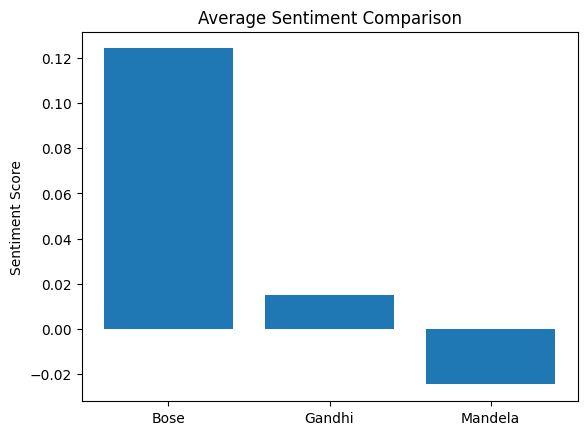

In [11]:
leaders = ["Bose", "Gandhi", "Mandela"]
averages = [
    np.mean(bose_scores),
    np.mean(gandhi_scores),
    np.mean(mandela_scores)
]

plt.bar(leaders, averages)
plt.title("Average Sentiment Comparison")
plt.ylabel("Sentiment Score")
plt.show()

In [12]:
def sentiment_distribution(scores):
    positive = len([s for s in scores if s > 0.05])
    negative = len([s for s in scores if s < -0.05])
    neutral = len(scores) - positive - negative
    return positive, negative, neutral

In [13]:
print("Bose:", sentiment_distribution(bose_scores))
print("Gandhi:", sentiment_distribution(gandhi_scores))
print("Mandela:", sentiment_distribution(mandela_scores))

Bose: (24, 18, 6)
Gandhi: (26, 24, 17)
Mandela: (173, 178, 139)


In [14]:
documents = [bose_clean, gandhi_clean, mandela_clean]

vectorizer = TfidfVectorizer(max_features=20)
X = vectorizer.fit_transform(documents)

feature_names = vectorizer.get_feature_names_out()

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

def get_top_bigrams(text, top_n=5):
    vectorizer = TfidfVectorizer(ngram_range=(2,2), stop_words='english')
    X = vectorizer.fit_transform([text])

    feature_names = vectorizer.get_feature_names_out()
    scores = X.toarray()[0]

    sorted_indices = scores.argsort()[::-1]

    top_bigrams = [feature_names[i] for i in sorted_indices[:top_n]]

    return top_bigrams

print("Top phrases for Bose:")
print(get_top_bigrams(bose_clean))

print("\nTop phrases for Gandhi:")
print(get_top_bigrams(gandhi_clean))

print("\nTop phrases for Mandela:")
print(get_top_bigrams(mandela_clean))

Top phrases for Bose:
['money material', 'men money', 'total mobilization', 'east asia', 'indian east']

Top phrases for Gandhi:
['british people', 'power come', 'resolution let', 'point view', 'consider point']

Top phrases for Mandela:
['south africa', 'communist party', 'african people', 'civil war', 'south african']


In [16]:
bigram_vectorizer = TfidfVectorizer(ngram_range=(2,2), max_features=15)
X_bigram = bigram_vectorizer.fit_transform(documents)

bigram_features = bigram_vectorizer.get_feature_names_out()

In [17]:
for i, leader in enumerate(leaders):
    print("\nTop phrases for", leader)
    scores = X_bigram[i].toarray()[0]
    top_indices = scores.argsort()[-5:][::-1]

    for index in top_indices:
        print(bigram_features[index])


Top phrases for Bose
money material
south african
white supremacy
south africa
per cent

Top phrases for Gandhi
money material
south african
white supremacy
south africa
per cent

Top phrases for Mandela
south africa
communist party
african people
civil war
african want


In [18]:
svd = TruncatedSVD(n_components=2)
X_lsa = svd.fit_transform(X)

terms = vectorizer.get_feature_names_out()

for i, comp in enumerate(svd.components_):
    print("\nTopic", i+1)
    terms_in_topic = [terms[j] for j in comp.argsort()[-10:]]
    print(terms_in_topic)


Topic 1
['policy', 'country', 'would', 'african', 'want', 'war', 'people', 'one', 'struggle', 'freedom']

Topic 2
['organization', 'country', 'south', 'africa', 'umkhonto', 'political', 'communist', 'white', 'anc', 'african']


In [19]:
similarity = cosine_similarity(X)

print("\nCosine Similarity Matrix:")
print(similarity)


Cosine Similarity Matrix:
[[1.         0.73240161 0.17801558]
 [0.73240161 1.         0.25984087]
 [0.17801558 0.25984087 1.        ]]


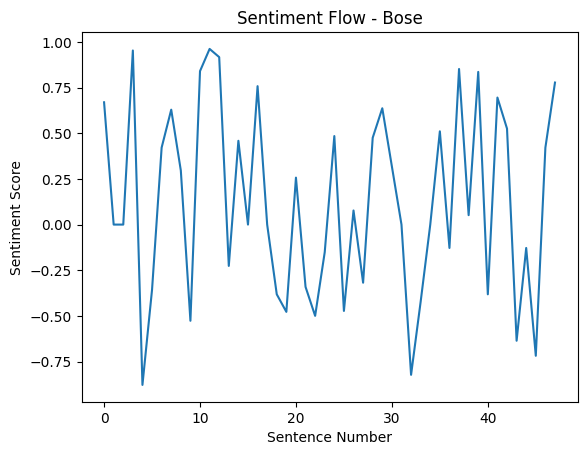

In [20]:
plt.figure()
plt.plot(bose_scores)
plt.title("Sentiment Flow - Bose")
plt.xlabel("Sentence Number")
plt.ylabel("Sentiment Score")
plt.show()

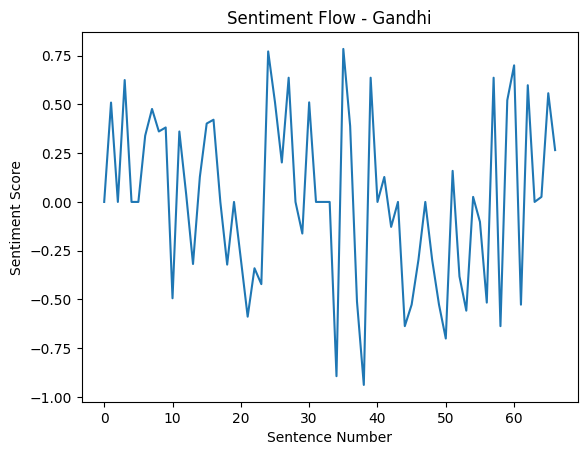

In [21]:
plt.figure()
plt.plot(gandhi_scores)
plt.title("Sentiment Flow - Gandhi")
plt.xlabel("Sentence Number")
plt.ylabel("Sentiment Score")
plt.show()

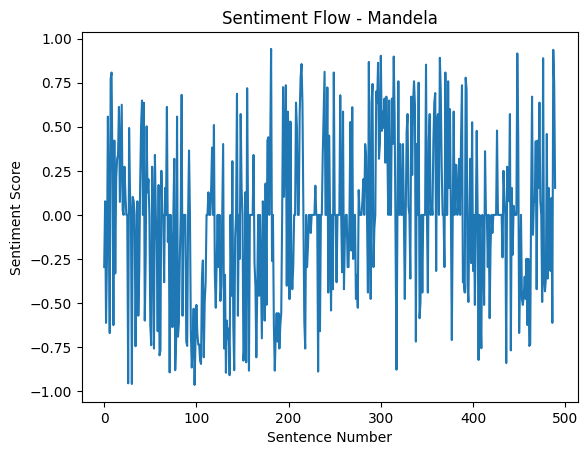

In [22]:
plt.figure()
plt.plot(mandela_scores)
plt.title("Sentiment Flow - Mandela")
plt.xlabel("Sentence Number")
plt.ylabel("Sentiment Score")
plt.show()

In [23]:
from nltk.tokenize import sent_tokenize

def show_extreme_sentences(text, scores, leader_name):
    sentences = sent_tokenize(text)

    max_index = scores.index(max(scores))
    min_index = scores.index(min(scores))

    print("====", leader_name, "====")
    print("\nMost Positive Sentence:")
    print(sentences[max_index])

    print("\nMost Negative Sentence:")
    print(sentences[min_index])
    print("\n----------------------\n")

show_extreme_sentences(bose_text, bose_scores, "Bose")
show_extreme_sentences(gandhi_text, gandhi_scores, "Gandhi")
show_extreme_sentences(mandela_text, mandela_scores, "Mandela")

==== Bose ====

Most Positive Sentence:
Through the grace of Providence and through the help of generous Nippon, it has become possible for Indians in East Asia are united to a man in the endeavour to win freedom and all the religious and other differences that the British tried to engineer inside India, simply do not exist in East Asia.

Most Negative Sentence:
The British are engaged in a worldwide struggle and in the course of struggle they have suffered defeat after defeat on so many fronts.

----------------------

==== Gandhi ====

Most Positive Sentence:
I have faith, therefore, that if, in spite of our shortcomings, the big thing does happen, it will be because God wanted to help us by crowning with success our silent, unremitting Sadhana for the last twenty-two years.

Most Negative Sentence:
But it is my conviction that inasmuch as these struggles were fought with the weapon of violence they failed to realize the democratic ideal.

----------------------

==== Mandela ====

M

In [24]:
def sentiment_percent(scores):
    positive = len([s for s in scores if s > 0.05])
    negative = len([s for s in scores if s < -0.05])
    neutral = len(scores) - positive - negative

    total = len(scores)

    return {
        "Positive %": round(positive/total * 100, 2),
        "Negative %": round(negative/total * 100, 2),
        "Neutral %": round(neutral/total * 100, 2)
    }

print("Bose:", sentiment_percent(bose_scores))
print("Gandhi:", sentiment_percent(gandhi_scores))
print("Mandela:", sentiment_percent(mandela_scores))

Bose: {'Positive %': 50.0, 'Negative %': 37.5, 'Neutral %': 12.5}
Gandhi: {'Positive %': 38.81, 'Negative %': 35.82, 'Neutral %': 25.37}
Mandela: {'Positive %': 35.31, 'Negative %': 36.33, 'Neutral %': 28.37}


In [25]:
def vocabulary_stats(text):
    words = text.lower().split()
    unique_words = set(words)

    total_words = len(words)
    unique_count = len(unique_words)

    richness = unique_count / total_words

    return total_words, unique_count, round(richness, 3)

print("Bose:", vocabulary_stats(bose_text))
print("Gandhi:", vocabulary_stats(gandhi_text))
print("Mandela:", vocabulary_stats(mandela_text))

Bose: (906, 407, 0.449)
Gandhi: (1094, 477, 0.436)
Mandela: (10700, 2653, 0.248)


In [26]:
def avg_sentence_length(text):
    sentences = sent_tokenize(text)
    lengths = [len(sentence.split()) for sentence in sentences]
    return round(sum(lengths)/len(lengths), 2)

print("Bose Avg Sentence Length:", avg_sentence_length(bose_text))
print("Gandhi Avg Sentence Length:", avg_sentence_length(gandhi_text))
print("Mandela Avg Sentence Length:", avg_sentence_length(mandela_text))

Bose Avg Sentence Length: 18.88
Gandhi Avg Sentence Length: 16.33
Mandela Avg Sentence Length: 21.84


In [27]:
summary = pd.DataFrame({
    "Leader": ["Bose", "Gandhi", "Mandela"],
    "Avg Sentiment": [
        round(np.mean(bose_scores), 3),
        round(np.mean(gandhi_scores), 3),
        round(np.mean(mandela_scores), 3)
    ],
    "Avg Sentence Length": [
        avg_sentence_length(bose_text),
        avg_sentence_length(gandhi_text),
        avg_sentence_length(mandela_text)
    ]
})

summary

,Leader,Avg Sentiment,Avg Sentence Length
0,Bose,0.124,18.88
1,Gandhi,0.015,16.33
2,Mandela,-0.025,21.84
